<a href="https://colab.research.google.com/github/broistg/ML-Assignment-DNAC1/blob/main/notebooks/BTL2_traditional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0.&nbsp;User manual

This Google Colab file implements a traditional machine learning pipeline for a text dataset (20 Newsgroups). To run the entire workflow, simply click Run All (library installation and dataset loading are automated).

# 1.&nbsp;Prepare the necessary data and libraries

## 1.1.&nbsp;Verify and install necessary libraries

In [ ]:
# Verify required libraries
import sys
import subprocess

def pip_install(packages):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + packages)

pip_install(["scikit-learn", "pandas", "matplotlib", "seaborn", "wget", "WordCloud"])

# Import libraries
import wget
import os
from collections import Counter
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_files
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, classification_report
import torch

# Set seed random
RND = 42
np.random.seed(RND)
import random
random.seed(RND)
torch.manual_seed(RND)

## 1.2.&nbsp;Download and store the dataset

In [ ]:
url = "http://qwone.com/~jason/20Newsgroups/20news-18828.tar.gz"
filename = "20news-18828.tar.gz"
folder = "20news-18828"

if not os.path.exists(folder):
    if not os.path.exists(filename):
        print("Downloading file .tar.gz...")
        !wget -q {url} -O {filename}
        print("Done!")
    else:
        print("File .tar.gz already exists.")

    print("Extracting")
    !tar -xzf {filename}
    print("Done!")
else:
    print("Dataset already exists.")

# Load dataset
dataset = load_files("20news-18828", encoding="latin1")

print("\nNumber of documents:", len(dataset.data))
print("Number of classes:", len(dataset.target_names))

Done!
Extracting
Done!

Number of documents: 18828
Number of classes: 20


In [ ]:
import re
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|[\w\.-]+@[\w\.-]+|\d+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

dataset_cleaned = [clean_text(doc) for doc in dataset.data]

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# 2.&nbsp;Exploratory Data Analysis (EDA)

In [ ]:
# Print the first 3 documents
for i in range(3):
    print(f"Document {i+1}")
    print("Target:", dataset.target_names[dataset.target[i]])
    print(dataset.data[i])

Document 1
Target: comp.graphics
From: haston@utkvx.utk.edu (Haston, Donald Wayne)
Subject: Church related graphics

I am looking for some good quality graphics files which are
suitable for use in church-related presentations. I prefer vector,
but anything would be helpful.

If you know of bulletin boards which have collections of this nature, or
commercial products, please inform me by email:

HASTON@UTKVX.UTK.EDU

Wayne Haston




Document 2
Target: comp.graphics
From: jr0930@eve.albany.edu (REGAN JAMES P)
Subject: Re: Pascal-Fractals

Apparently, my editor didn't do what I wanted it to do, so I'll try again.

i'm looking for any programs or code to do simple animation and/or
drawing using fractals in TurboPascal for an IBM
              Thanks in advance
-- 
 |||||||||||   		 	   ||||||||||| 
_|||||||||||_______________________|||||||||||_      jr0930@eve.albany.edu
-|||||||||||-----------------------|||||||||||-     jr0930@Albnyvms.bitnet
 |||||||||||  GO HEAVY OR GO HOME  ||||||||

Value counts for target:
rec.sport.hockey            999
soc.religion.christian      997
rec.motorcycles             994
rec.sport.baseball          994
sci.crypt                   991
sci.med                     990
rec.autos                   990
sci.space                   987
comp.os.ms-windows.misc     985
comp.sys.ibm.pc.hardware    982
sci.electronics             981
comp.windows.x              980
comp.graphics               973
misc.forsale                972
comp.sys.mac.hardware       961
talk.politics.mideast       940
talk.politics.guns          910
alt.atheism                 799
talk.politics.misc          775
talk.religion.misc          628
Name: count, dtype: int64


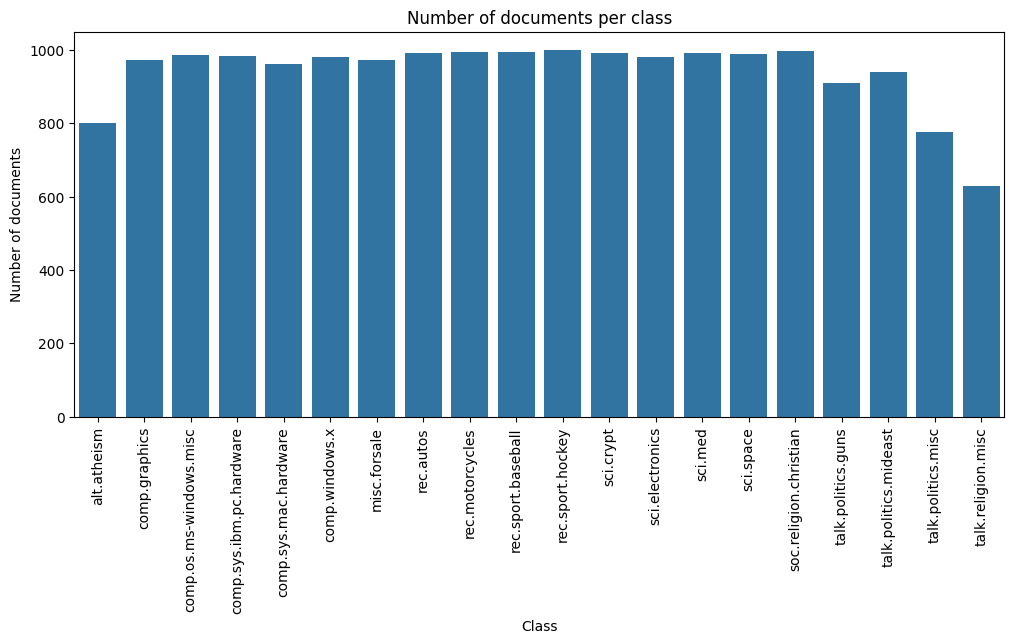

In [ ]:
# Value counts for target
target_series = pd.Series(dataset.target)
target_series_named = target_series.map(lambda x: dataset.target_names[x])

print("Value counts for target:")
print(target_series_named.value_counts())

counts = Counter(dataset.target)

plt.figure(figsize=(12,5))
sns.barplot(x=list(counts.keys()), y=list(counts.values()))
plt.xticks(range(len(dataset.target_names)), dataset.target_names, rotation=90)
plt.title("Number of documents per class")
plt.ylabel("Number of documents")
plt.xlabel("Class")
plt.show()

Average document length: 272.49479498619075
Median document length: 164.0
Maximum document length: 11795
Minimum document length: 5


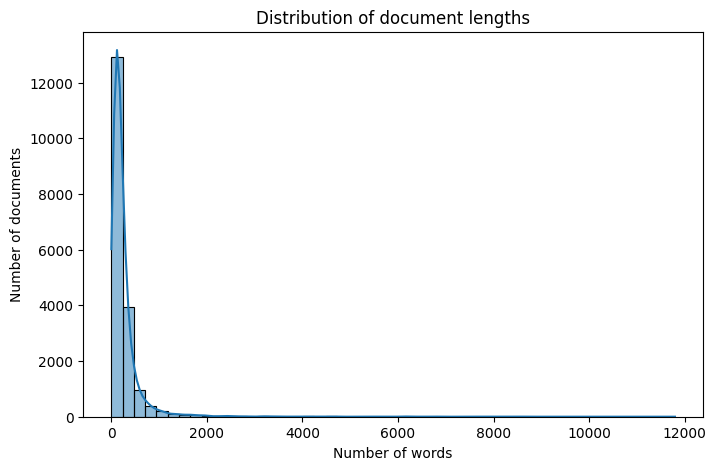

In [ ]:
# Document lengths
doc_lengths = [len(doc.split()) for doc in dataset.data]

print("Average document length:", np.mean(doc_lengths))
print("Median document length:", np.median(doc_lengths))
print("Maximum document length:", np.max(doc_lengths))
print("Minimum document length:", np.min(doc_lengths))

plt.figure(figsize=(8,5))
sns.histplot(doc_lengths, bins=50, kde=True)
plt.title("Distribution of document lengths")
plt.xlabel("Number of words")
plt.ylabel("Number of documents")
plt.show()

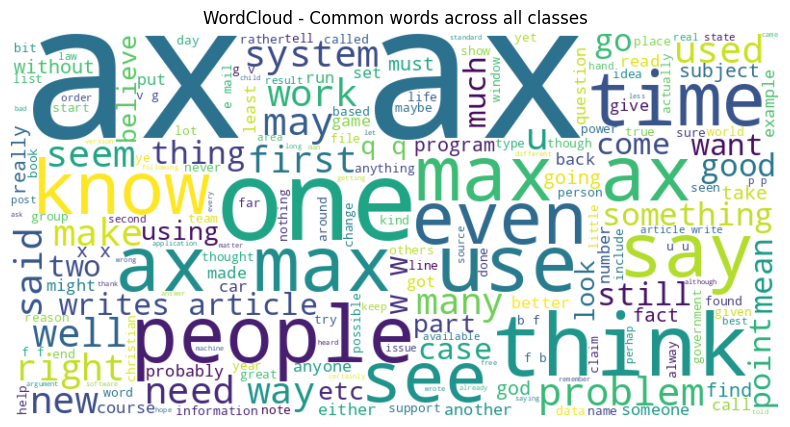

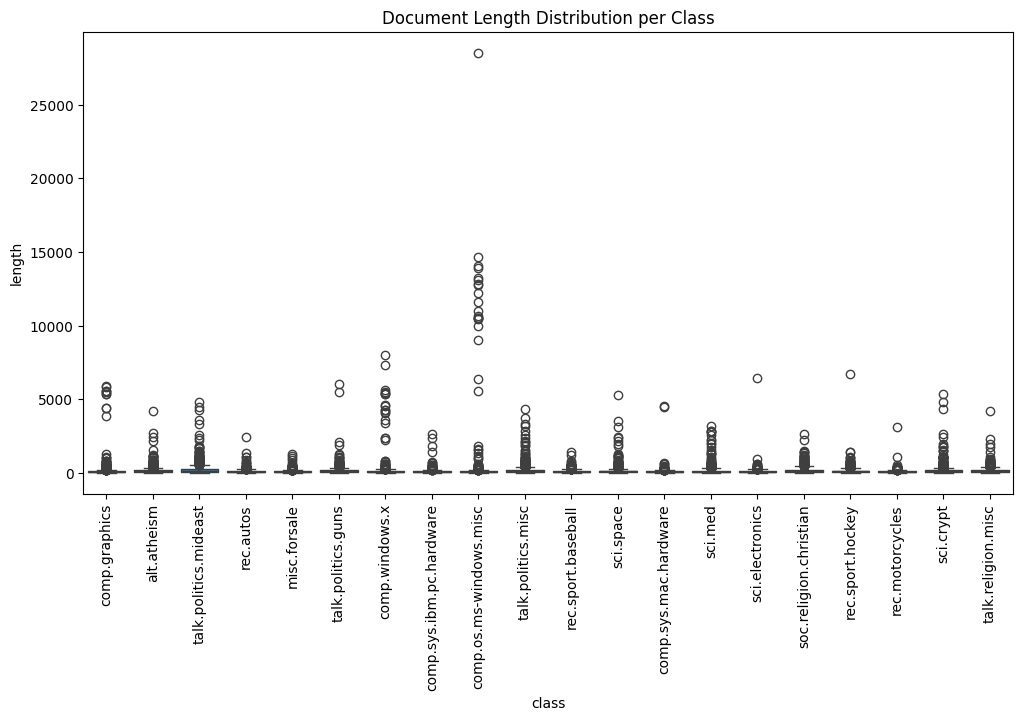

In [ ]:
from wordcloud import WordCloud

text_all = " ".join(dataset_cleaned)
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=200).generate(text_all)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud - Common words across all classes")
plt.show()

doc_lengths = [len(doc.split()) for doc in dataset_cleaned]
df_length = pd.DataFrame({"length": doc_lengths, "class": [dataset.target_names[i] for i in dataset.target]})
plt.figure(figsize=(12, 6))
sns.boxplot(x="class", y="length", data=df_length)
plt.xticks(rotation=90)
plt.title("Document Length Distribution per Class")
plt.show()

Vocabulary size (including stopwords): 170781


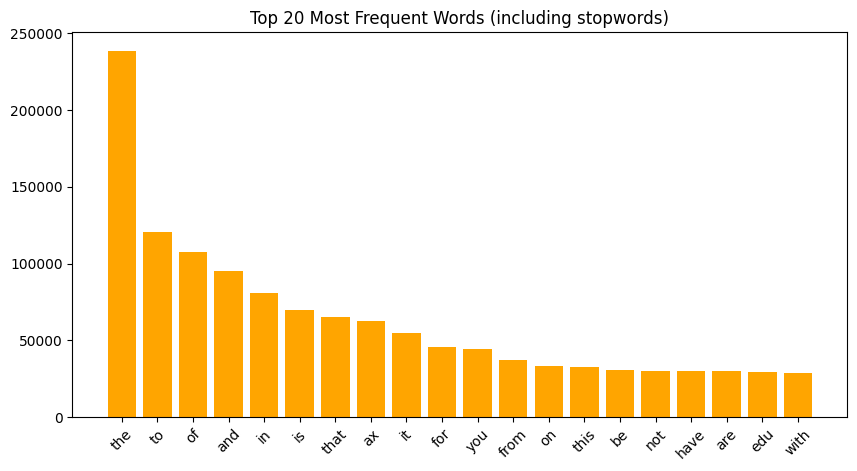

Vocabulary size (stopwords removed): 170470


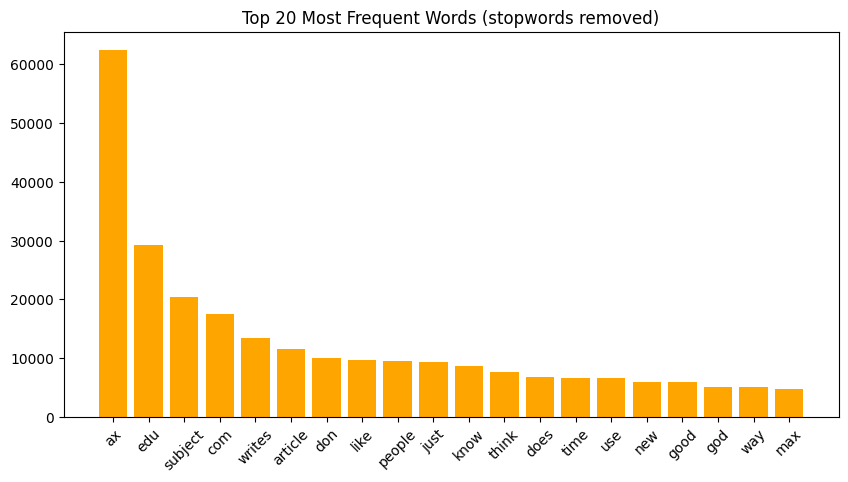

In [ ]:
# Plot top 10 words and vocabulary size (including stopwords)
vectorizer = CountVectorizer(stop_words=None)
X = vectorizer.fit_transform(dataset.data)

word_counts = np.asarray(X.sum(axis=0)).ravel()
top_indices = word_counts.argsort()[::-1][:20]

vocab_1 = vectorizer.get_feature_names_out()
print(f"Vocabulary size (including stopwords): {len(vocab_1)}")

plt.figure(figsize=(10,5))
plt.bar([vocab_1[i] for i in top_indices], word_counts[top_indices], color='orange')
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words (including stopwords)")
plt.show()

# Plot top 10 words and vocabulary size (stopwords removed)
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(dataset.data)

word_counts = np.asarray(X.sum(axis=0)).ravel()
top_indices = word_counts.argsort()[::-1][:20]

vocab_2 = vectorizer.get_feature_names_out()
print(f"Vocabulary size (stopwords removed): {len(vocab_2)}")

plt.figure(figsize=(10,5))
plt.bar([vocab_2[i] for i in top_indices], word_counts[top_indices], color='orange')
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words (stopwords removed)")
plt.show()

# 3.&nbsp;Feature Extraction with Text Preprocessing

## 3.1.&nbsp;Train/Val/Test split with stratification

In [ ]:
# Split dataset into train/val/test sets
# X = dataset.data
X = dataset_cleaned
y = dataset.target


X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=RND, stratify=dataset.target)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=RND, stratify=y_temp)

print('Original dataset shape:', len(dataset.data))
print('Split -> Train:', len(X_train), '   Validation:', len(X_val), '   Test:', len(X_test))

Original dataset shape: 18828
Split -> Train: 13179    Validation: 2824    Test: 2825


## 3.2.&nbsp;Build Vectorizer

In [ ]:
def build_vectorizer(config):
    stop_words = 'english' if config['stop_words'] else None

    if config['vectorizer'] == 'BoW':
        vectorizer = CountVectorizer(max_features=config['max_features'],
                                     lowercase=True,
                                     stop_words=stop_words,
                                     analyzer=config['token'],
                                     ngram_range=config['ngram']
        )
    elif config['vectorizer'] == 'TF-IDF':
        vectorizer = TfidfVectorizer(max_features=config['max_features'],
                                     lowercase=True,
                                     stop_words=stop_words,
                                     analyzer=config['token'],
                                     ngram_range=config['ngram'],
                                     strip_accents='unicode',
                                     preprocessor=clean_text


    )
    else:
        raise ValueError(f"Unsupported vectorizer method: {config['vectorizer']}")

    return vectorizer

# 4.&nbsp;Training and Evaluation

## 4.1.&nbsp;Model Training and Testing

In [ ]:
from sklearn.model_selection import GridSearchCV
import joblib
def train_and_test(config, X_train, y_train, X_val, y_val, X_test, y_test):
    vectorizer = build_vectorizer(config)

    X_train_vec = vectorizer.fit_transform(X_train)
    X_val_vec = vectorizer.transform(X_val)
    X_test_vec = vectorizer.transform(X_test)

    np.save("X_train.npy", X_train_vec.toarray())
    np.save("X_val.npy", X_val_vec.toarray())
    np.save("X_test.npy", X_test_vec.toarray())

    X_train_dense = np.load("X_train.npy")
    X_val_dense = np.load("X_val.npy")
    X_test_dense = np.load("X_test.npy")

    model = globals()[config["model"]["name"]]
    params = config["model"]["params"]
    classifier = model(**params)
    if config["model"]["name"] in ["LogisticRegression", "SVC"]:
        param_grid = {}
        if config["model"]["name"] == "LogisticRegression":
            param_grid = {'C': [0.1, 1, 10]}
        elif config["model"]["name"] == "SVC":
            param_grid = {'C': [0.5, 1, 2]}

        grid = GridSearchCV(classifier, param_grid, cv=3, scoring='f1_weighted', n_jobs=-1)
        grid.fit(X_train_dense, y_train)
        classifier = grid.best_estimator_
        print(f"🔍 Best Params for {config['model']['name']}: {grid.best_params_}")
    classifier.fit(X_train_dense, y_train)

    # Evaluate on validation set
    y_pred = classifier.predict(X_val_dense)
    print(f"[Validation] {config['model']['name']}")
    print(classification_report(y_val, y_pred, digits=5))

    # Evaluate on test set
    y_pred = classifier.predict(X_test_dense)
    print(f"\n[Test] {config['model']['name']}")
    print(classification_report(y_test, y_pred, digits=5))
    joblib.dump(classifier, f"{config['model']['name']}_model.pkl")
    joblib.dump(vectorizer, f"{config['vectorizer']}_vectorizer.pkl")
    print(f"✅ Saved model and vectorizer for {config['model']['name']} with {config['vectorizer']}")

## 4.2.&nbsp;Model Comparison

In [ ]:
def model_comparision(X_train, y_train, X_val, y_val, X_test, y_test):
    param_grid = {
        'vectorizer': ['BoW', 'TF-IDF'],
        'classifier': [
            (LogisticRegression, {'max_iter': 400}),
            (SVC, {'kernel': 'linear', 'class_weight': 'balanced'}),
            (DecisionTreeClassifier, {}),
            (RandomForestClassifier, {}),
            (KNeighborsClassifier, {'n_neighbors': 5}),
            (MultinomialNB, {})
          ]
    }

    results = []
    for clf, clf_params in param_grid['classifier']:
        for v in param_grid['vectorizer']:
            if v == 'BoW':
                vectorizer = CountVectorizer(max_features=5000, lowercase=True, stop_words='english', analyzer='word', ngram_range=(1,2))
            else:
                vectorizer = TfidfVectorizer(max_features=5000, lowercase=True, stop_words='english', analyzer='word', ngram_range=(1,2))
            classifier = clf(**clf_params)

            X_train_vec = vectorizer.fit_transform(X_train)
            X_val_vec = vectorizer.transform(X_val)
            X_test_vec = vectorizer.transform(X_test)

            classifier.fit(X_train_vec, y_train)

            y_pred = classifier.predict(X_test_vec)

            acc = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred, average='weighted')
            recall = recall_score(y_test, y_pred, average='weighted')
            f1 = f1_score(y_test, y_pred, average='weighted')

            results.append({
                "Classifier": clf.__name__,
                "Vectorizer": v,
                "Accuracy": round(acc, 5),
                "Weighted-Precision": round(precision, 5),
                "Weighted-Recall": round(recall, 5),
                "Weighted-F1": round(f1, 5),
            })

    results = pd.DataFrame(results)

    fig = go.Figure(data=[go.Table(
        header=dict(values=list(results.columns),
                    fill_color='darkslateblue', font_color='white', align='center'),
        cells=dict(values=[results[col] for col in results.columns],
                  fill_color='lavender', font_color='black', align='center', height=25)
    )])

    fig.update_layout(title_text="Model Comparison Results", title_x=0.5)
    fig.show()

    plt.figure(figsize=(10, 6))
    sns.barplot(data=results, x='Classifier', y='Accuracy', hue='Vectorizer')
    plt.title("Accuracy Comparison between Models and Vectorizers")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 5.&nbsp;Choose model configuration

**Model options (common classifiers)**
*   **LogisticRegression:** 'max_iter' , 'class_weight' , 'random_state' , ...
*   **SVC:** 'kernel' , 'C' , 'gamma' , ...
*   **DecisionTreeClassifier:** 'criterion' , 'max_depth' , 'min_samples_split' , 'min_samples_leaf' , ...
*   **RandomForestClassifier:** 'n_estimators' , 'criterion' , 'max_depth' , 'min_samples_split' , 'min_samples_leaf' , ...
*   **KNeighborsClassifier:** 'n_neighbors' , 'weights' , 'metric' , ...
*   **MultinomialNB:** 'priors' , 'var_smoothing'.


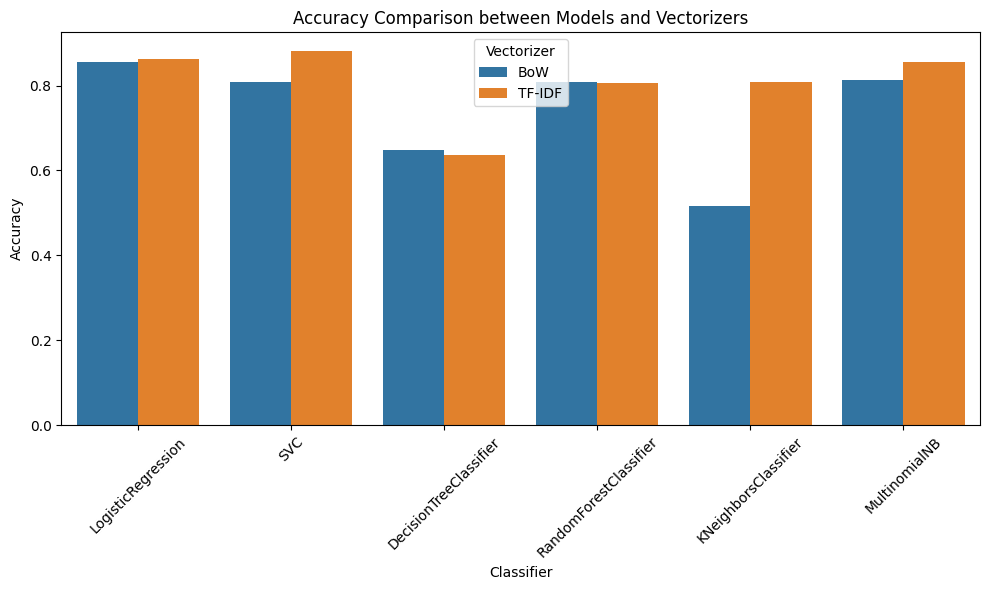

In [ ]:
config = {
    'token': 'word',
    'stop_words': True,
    'ngram': (1, 1),
    'vectorizer': 'TF-IDF',
    'max_features': 5000,
    'model': {
        'name': 'compare',
        'params': {
            'max_iter': 300
        }
    }
}

if config['model']['name'] == 'compare':
    model_comparision(X_train, y_train, X_val, y_val, X_test, y_test)
else:
    train_and_test(config, X_train, y_train, X_val, y_val, X_test, y_test)